[2026-08-05 03:18:24] [info     ] 计算因子，区间：2021-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 03:40:10] [info     ] 读取因子库，区间：2021-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 03:40:11] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 03:40:26] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 03:40:39] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2021-01-04 至 2024-12-31
[2026-08-05 03:40:39] [info     ] ========== 数据检查 ==========
[2026-08-05 03:40:39] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_l

时段,IC
2024-01-15~2024-02-08,0.0008
2024-09-24~2024-10-08,0.0372

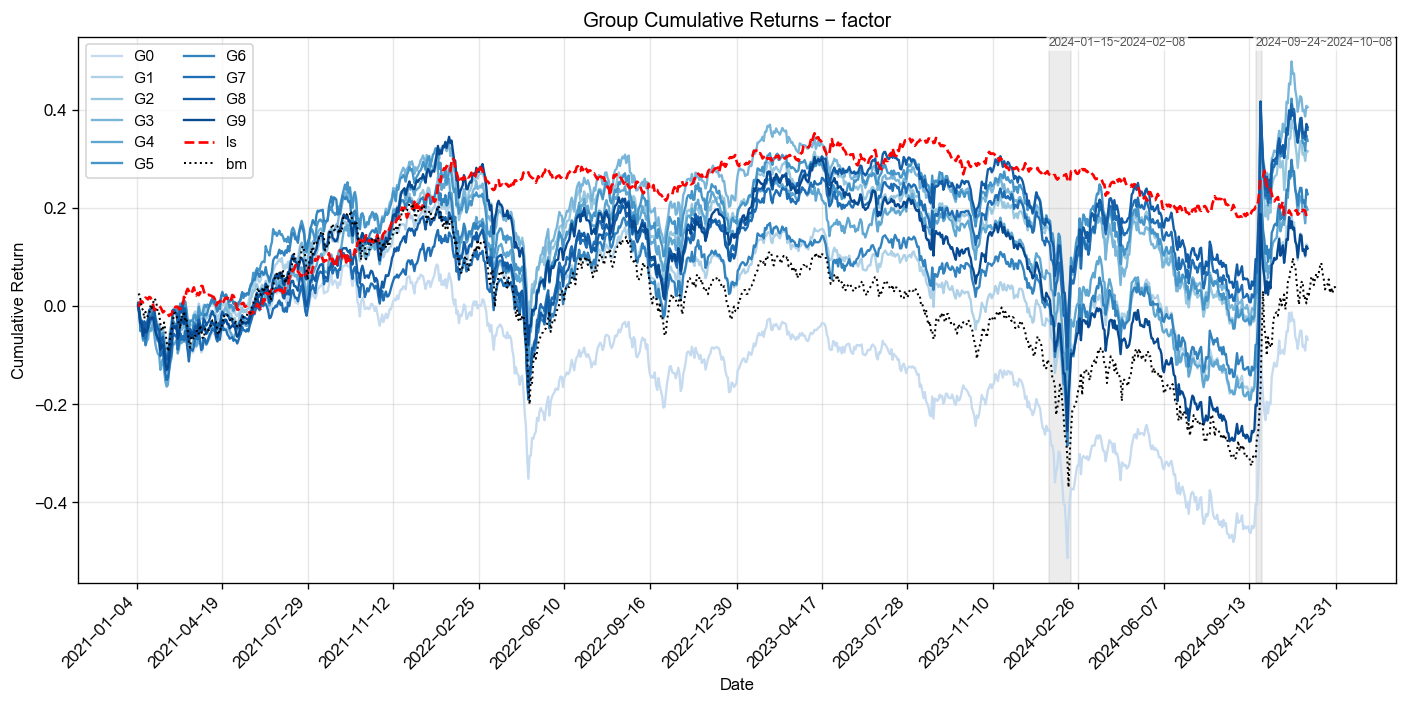
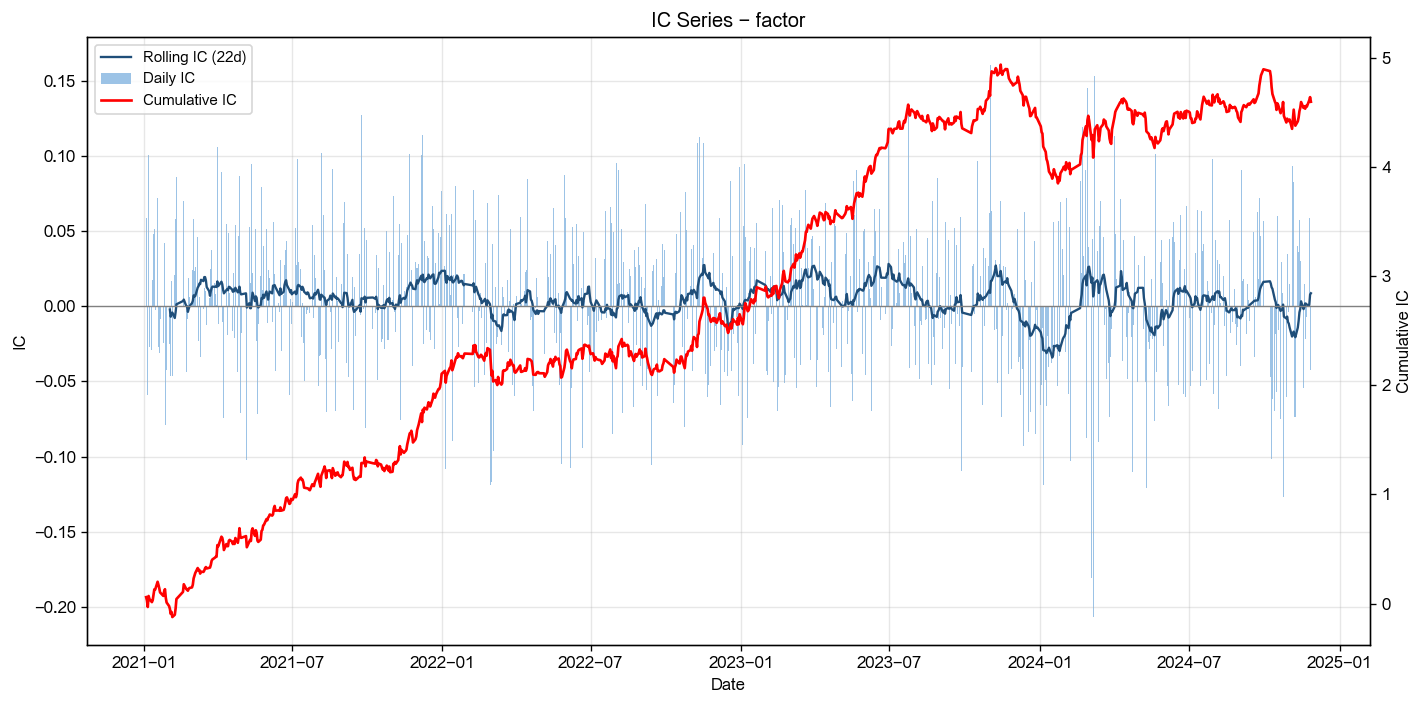
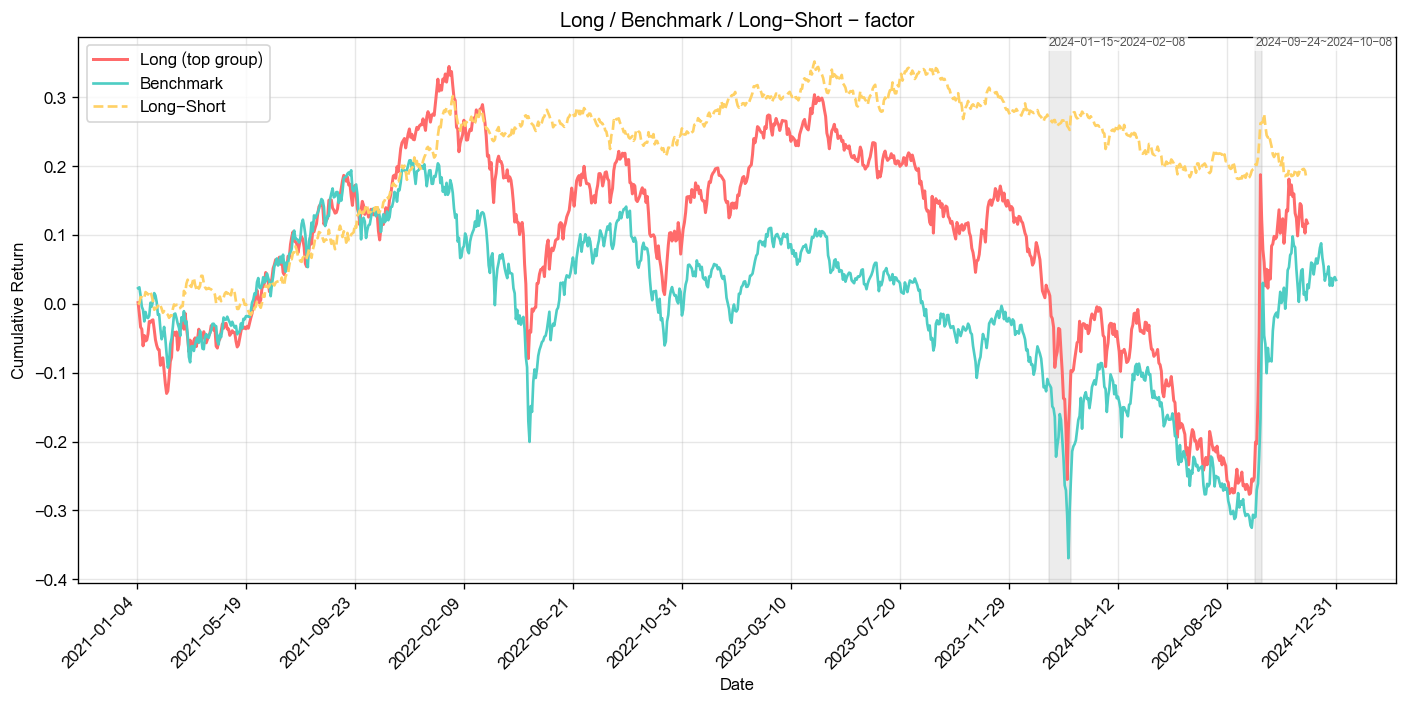
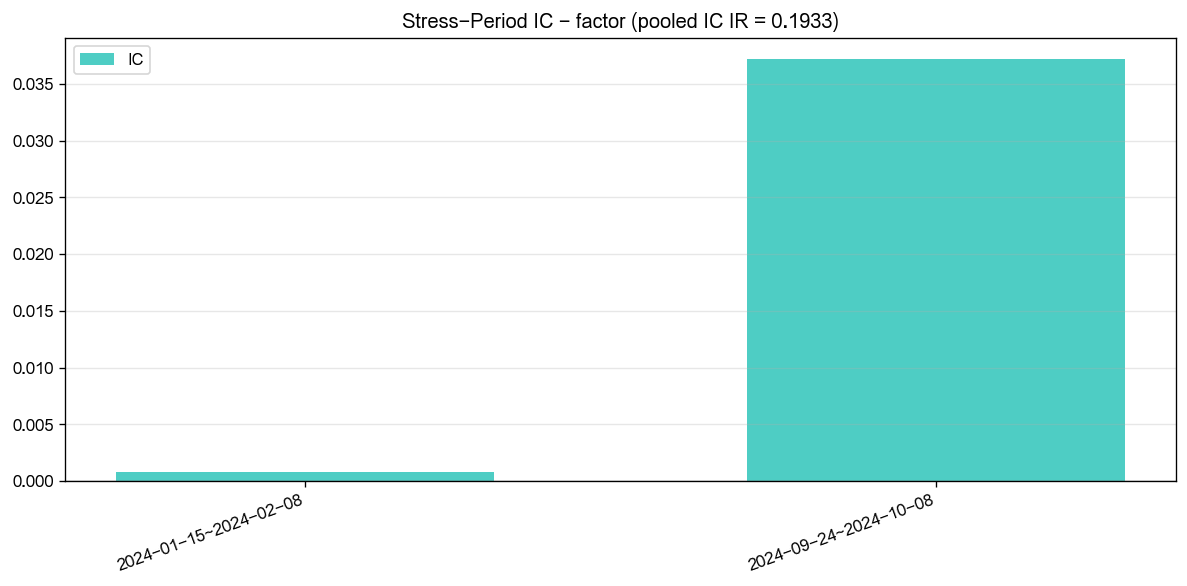
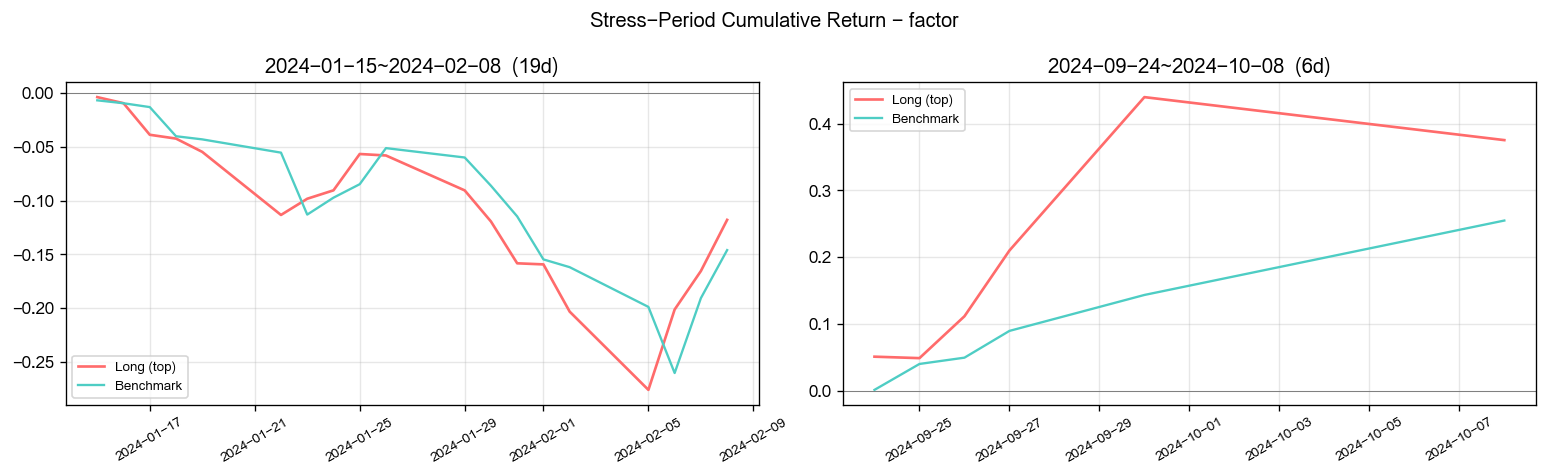

[2026-08-05 03:41:28] [info     ] ========== 因子池回归 ==========
[2026-08-05 03:41:29] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1753 rows=1604641 start_date=2021-01-04
[2026-08-05 03:41:45] [info     ] 获取收益率数据, 耗时: 17.1299 秒
[2026-08-05 03:41:46] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.2459 秒
[2026-08-05 03:41:46] [info     ] 统计 回归结果, 耗时: 0.0227 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,debt_to_asset_lf,1.4870,0.0093,0.0063,0.9783
2,momentum_5,1.4733,0.0176,0.0120,0.9783
3,net_active_buy_amount_main,1.4194,0.0198,0.0140,0.9348
4,amount,1.4104,0.0241,0.0171,0.9130
5,gross_profit_rate_ttm,1.3807,0.0126,0.0091,0.9565
6,volatility_5,1.3393,0.0138,0.0103,0.9565
7,reversal_5,1.3381,0.0087,0.0065,0.9565
8,beta_000300SH_22,1.3273,0.0174,0.0131,1.0000
9,macd_hist_12_26_9,1.3190,0.0091,0.0069,0.9130
10,cci_14,1.3142,0.0266,0.0202,0.9565

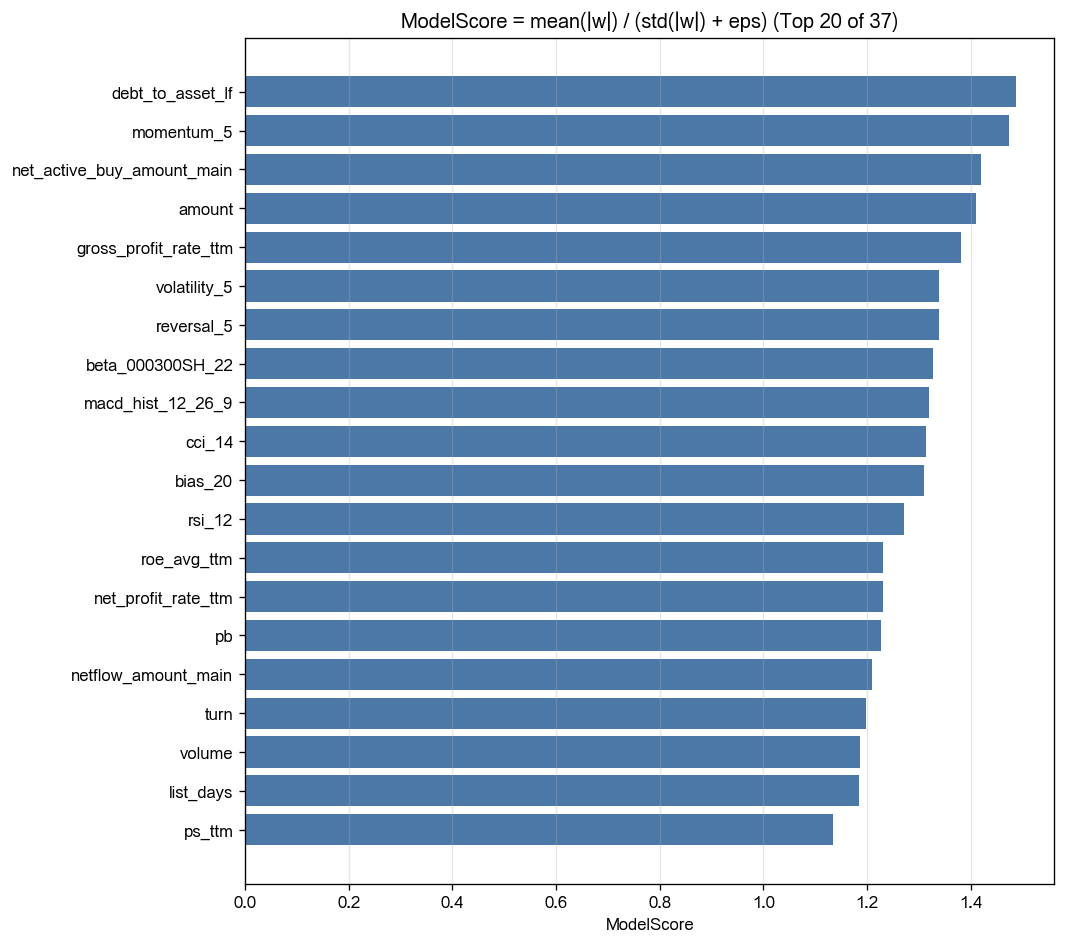
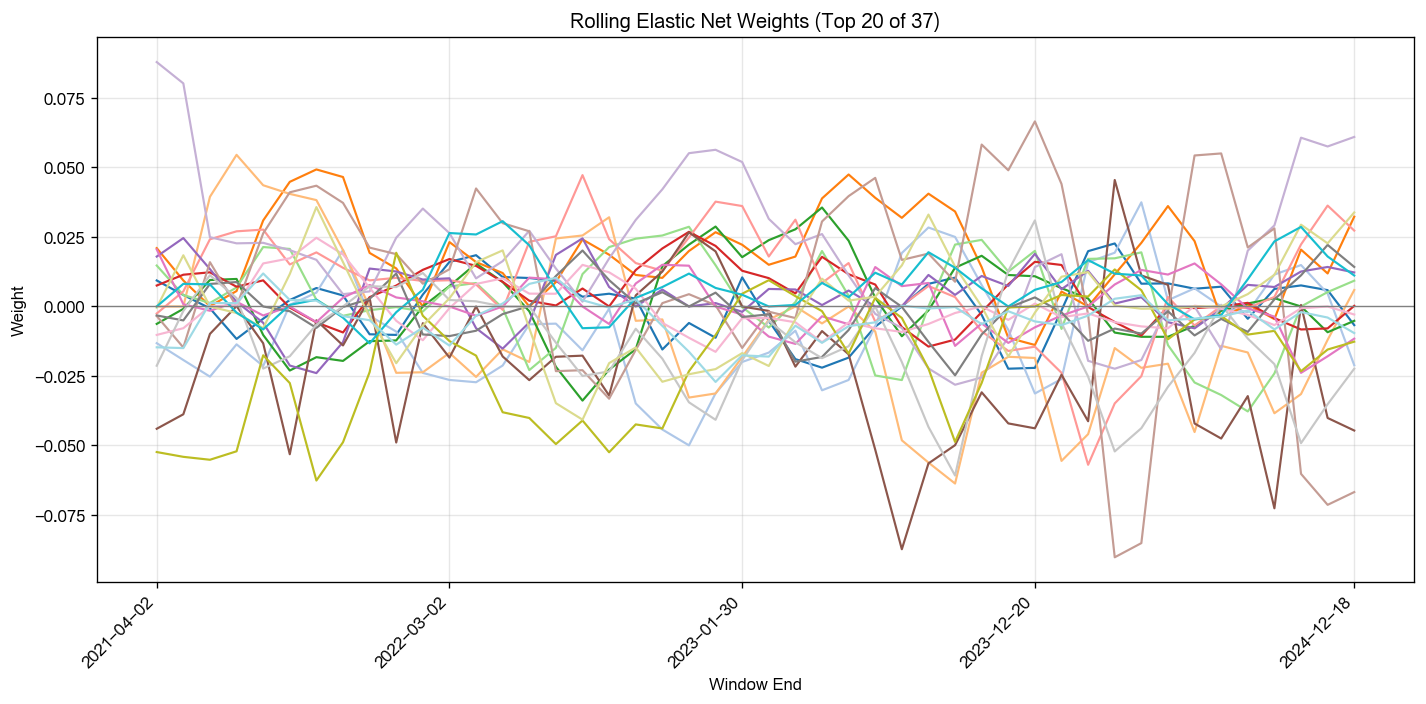
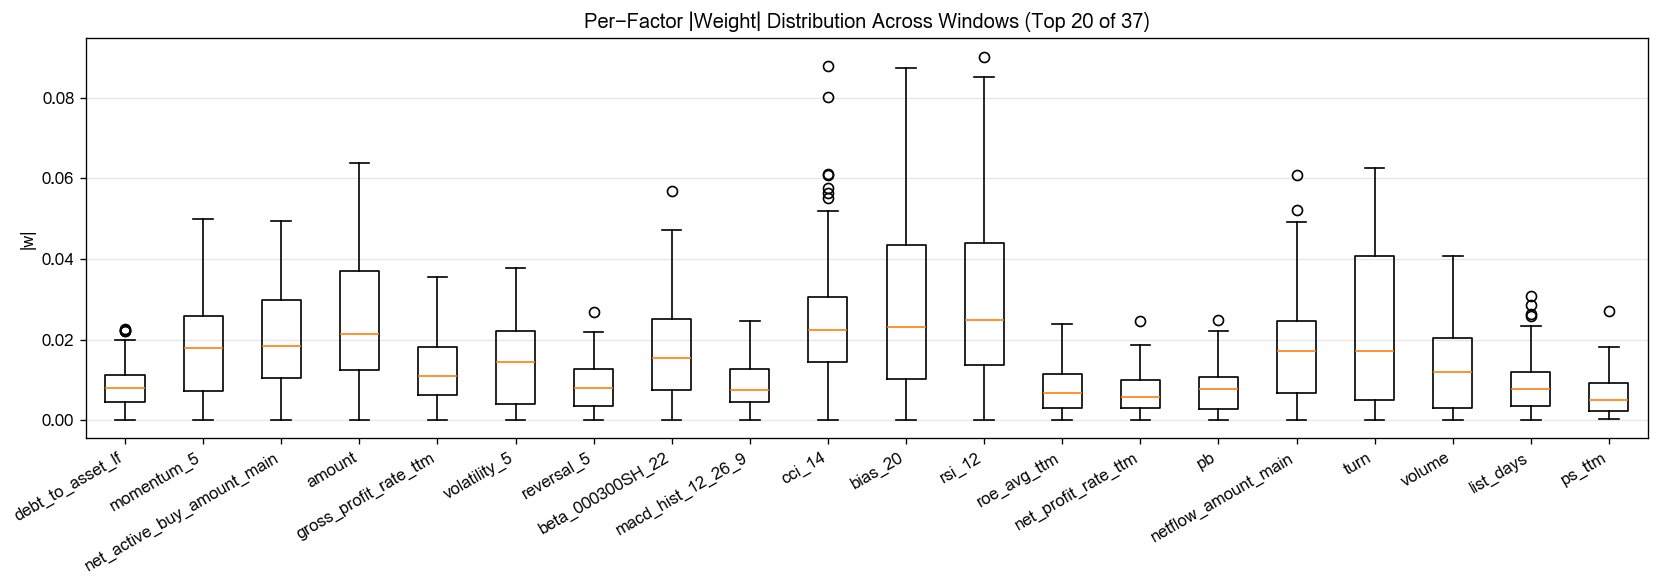
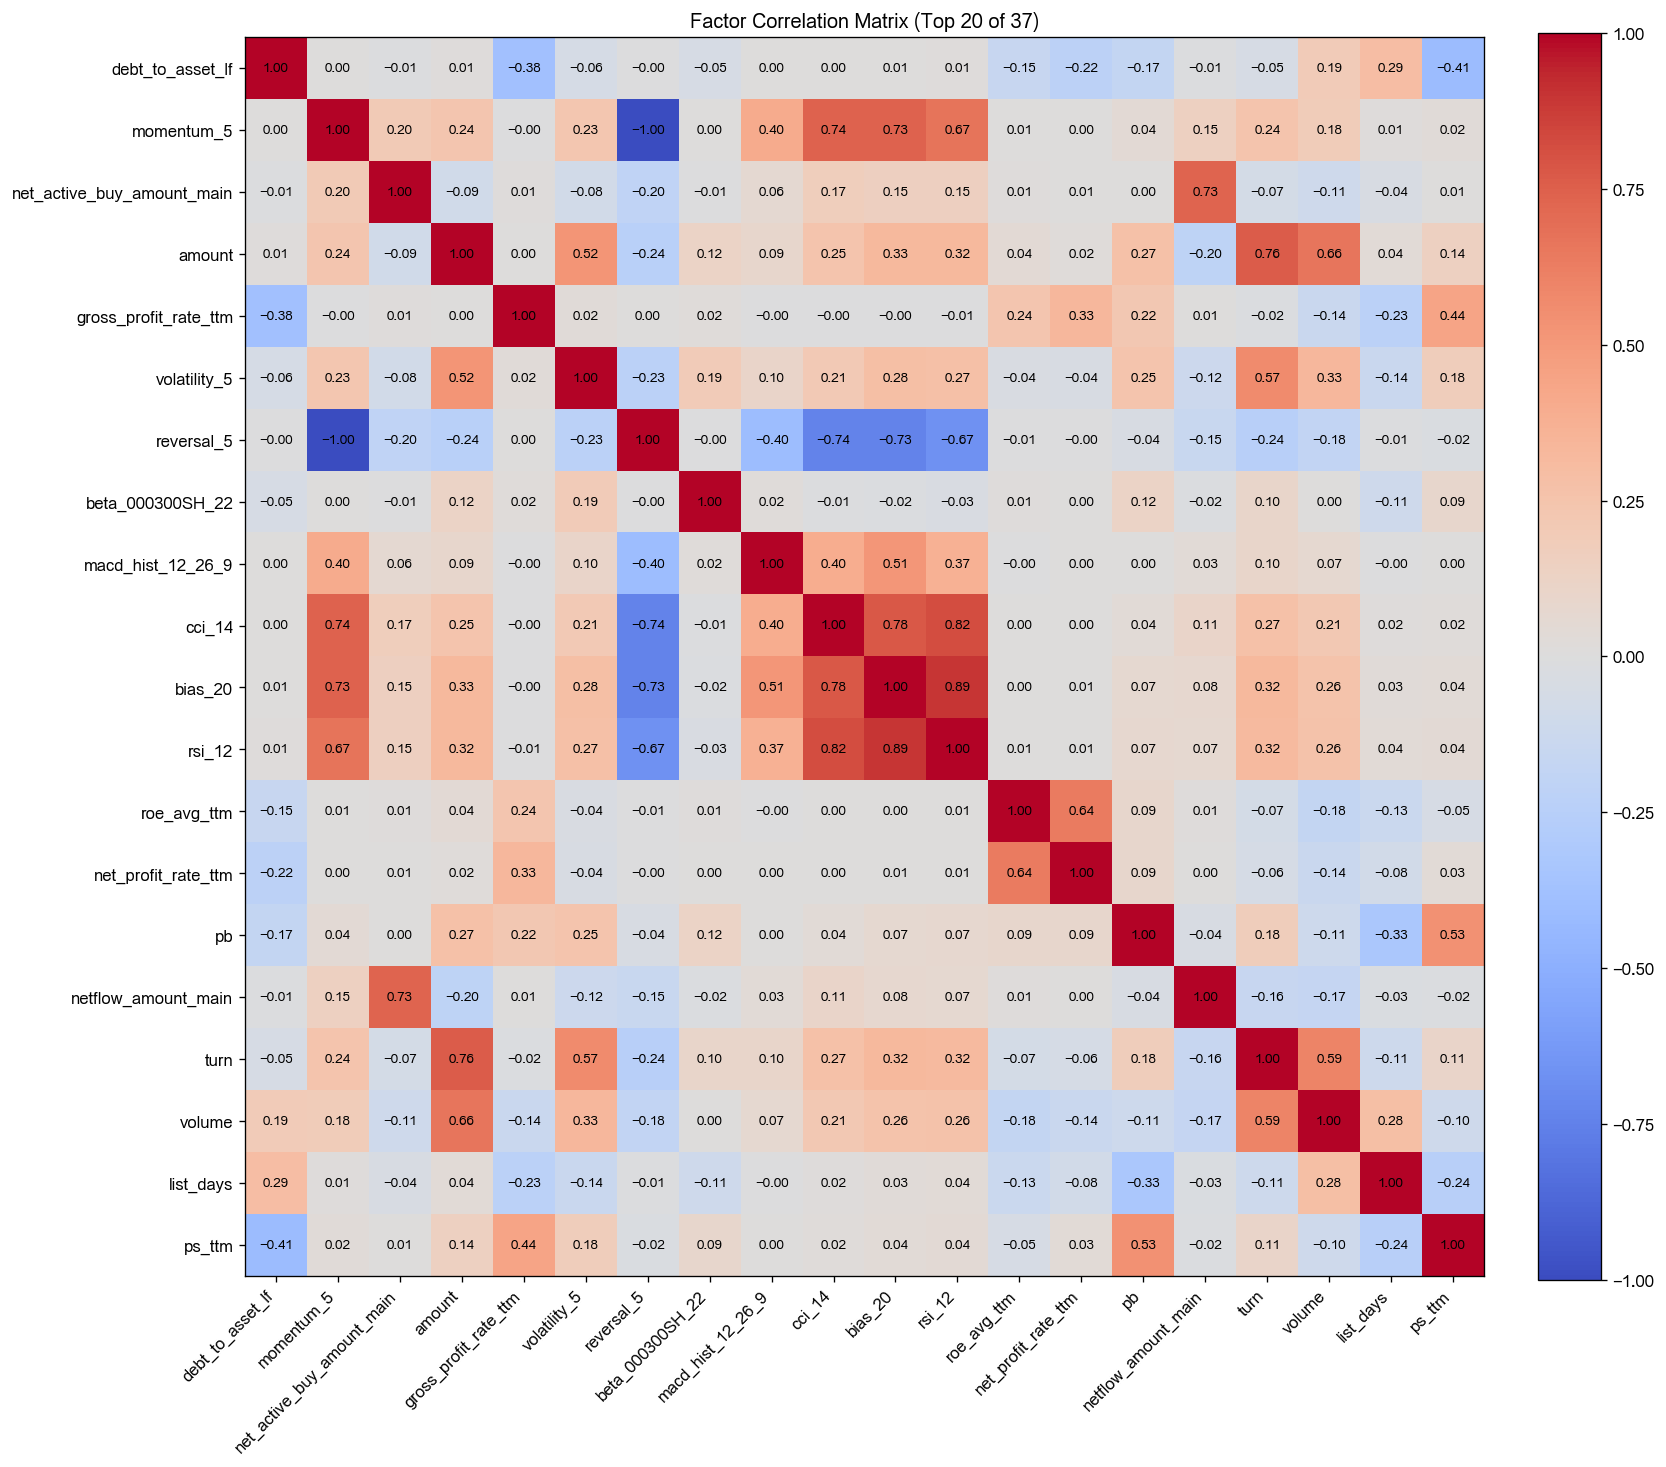

[2026-08-05 03:41:51] [warning  ] 返回的Outputs实例(size=143219458) 大于 64K, 将不会被缓存
[2026-08-05 03:41:51] [info     ] bigalpha_eval.v4 运行完成 [85.602s].


In [2]:
"""
构建一个基于过去64天由分钟聚合到日频的K线的傅里叶频谱分析结果的主频相位因子，因子值越靠近波峰越低，越靠近波谷越高；
可以取考察时间点在主频率上的相位与波峰或波谷的相位差的绝对值的倒数，再乘上-1或+1，最后取tanh压缩值域到[-1, 1]。
"""
def main(datasources, start_date, end_date):
    import pandas as pd
    import numpy as np
    import dai

    # 数据源：分钟K线表
    bar1m = datasources["bar1m"]

    # 起止时间处理（cutoff_ts 用于齐到日级别并截断到 end_date 所在自然日）
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    cutoff_ts = ed.normalize()

    # 额外向前取128天，用于滚动窗口计算时有足够历史
    lookback_start = (sd - pd.Timedelta(days=128)).strftime("%Y-%m-%d %H:%M:%S")

    # SQL：将 1m close 聚合为日频 close（按天取该日最后一个 close）
    sql = f"""
    WITH m AS (
        SELECT
            date,
            instrument,
            close
        FROM {bar1m}
        WHERE close IS NOT NULL
    ),
    d AS (
        SELECT
            CAST(strftime(date,'%Y-%m-%d') AS DATETIME) AS date,
            instrument,
            last(close ORDER BY date) AS close_d
        FROM m
        GROUP BY instrument, strftime(date, '%Y-%m-%d')
    )
    SELECT date, instrument, close_d
    FROM d
    """

    # 拉取日频数据（含向前 lookback），并压缩传输
    df = dai.query(sql, filters={"date": [lookback_start, end_date]}, compression=True).df()
    if df.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    # 日期归一化到自然日，避免时分秒干扰合并与对齐
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    # 截断到 end_date 当日（含）
    df = df[df["date"] <= cutoff_ts].copy()
    df = df.sort_values(["instrument", "date"])

    # 股票池：以交易日/标的为准，最终只对股票池范围输出
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    if stk_pool.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])
    stk_pool["date"] = pd.to_datetime(stk_pool["date"]).dt.normalize()
    stk_pool = stk_pool[stk_pool["date"] <= cutoff_ts].copy()

    # 交易日集合：用于生成每个 instrument 的输出日期序列
    trade_dates = pd.Index(sorted(stk_pool["date"].unique()))
    if trade_dates.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    def _phase_factor(g: pd.DataFrame) -> pd.DataFrame:
        # 单个 instrument 的处理：按日期排序并清洗 close
        g = g.sort_values("date").copy()
        g["close_d"] = pd.to_numeric(g["close_d"], errors="coerce")
        g = g.dropna(subset=["close_d"])
        if g.empty:
            return pd.DataFrame(columns=["date", "instrument", "factor"])

        inst = g["instrument"].iloc[0]
        # 转为以 date 为索引的序列，方便 reindex/ffill 对齐到完整日序列
        g = g.set_index("date")[["close_d"]].sort_index()

        # 输出日期：仅在 start_date ~ cutoff_ts 的交易日上计算/输出
        out_dates = trade_dates[(trade_dates >= sd.normalize()) & (trade_dates <= cutoff_ts)]
        if len(out_dates) == 0:
            return pd.DataFrame(columns=["date", "instrument", "factor"])

        factors = np.full(len(out_dates), np.nan, dtype=float)

        for i, t in enumerate(out_dates):
            # 滚动窗口：这里使用 64 天窗口（t-63 到 t，共64个自然日）
            # 注意：这与“向前取128天”并不矛盾，128天用于保证早期 t 也能拿到足够数据
            wstart = t - pd.Timedelta(days=63)
            hist_dates = pd.date_range(wstart, t, freq="D")

            # 对齐到连续自然日并前向填充，确保 FFT 输入无缺口
            s = g["close_d"].reindex(hist_dates).ffill()

            # 若仍有缺失（窗口开头缺历史）或长度不足则跳过
            if s.isna().any() or len(s) < 64:
                continue

            # 价格序列：log 变换 + 去均值，降低趋势/尺度影响
            x = np.log(s.values.astype(float) + 1e-12)
            x = x - np.nanmean(x)
            n = len(x)

            # 加窗（Hanning）减少频谱泄露
            w = np.hanning(n)
            xw = x * w

            # 实数 FFT：得到非负频率谱（rfft）
            X = np.fft.rfft(xw)
            amp = np.abs(X)         # 幅度谱
            phase = np.angle(X)     # 相位谱（[-pi, pi]）

            # 频率 bins 只有 DC 时无法取主频
            if len(amp) <= 1:
                continue

            # 去除 DC（均值项）避免其成为“主频”
            amp[0] = 0.0

            # 主频索引：幅度最大的频率 bin
            k = int(np.argmax(amp))
            if k <= 0 or k >= len(phase):
                continue

            # φ0：FFT 在该频率 k 上的相位（对应窗口起点/对齐方式下的相位）
            phi0 = float(phase[k])
            # ω：该频率对应的角频率
            omega = 2.0 * np.pi * k / n

            # 将相位外推出窗口末端时刻（索引 n-1），得到当前时点的主频相位
            phi_t = (omega * (n - 1) + phi0) % (2.0 * np.pi)

            # 计算两个角度的最小环形距离（考虑 2π 周期）
            def ang_dist(a, b):
                d = abs(a - b)
                return min(d, 2.0 * np.pi - d)

            # 峰相位（0）与 谷相位（π） 的距离：越近说明越接近峰/谷
            d_peak = ang_dist(phi_t, 0.0)
            d_trough = ang_dist(phi_t, np.pi)

            # 以距离的倒数作为“接近程度”，距离越小值越大；加 epsilon 防止除零
            dmin = min(d_peak, d_trough) + 1e-6

            # 符号约定：更接近谷 => 正；更接近峰 => 负
            sign = 1.0 if d_trough < d_peak else -1.0

            # 原始分数：符号/距离；再 tanh 压缩到 [-1, 1]
            raw = sign / dmin
            factors[i] = float(np.tanh(raw))

        # 输出：仅保留成功计算的日期
        out = pd.DataFrame({"date": out_dates, "instrument": inst, "factor": factors})
        out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["factor"])
        return out

    # 对每个 instrument 并行/分组计算因子
    res = df.groupby("instrument", group_keys=False).apply(_phase_factor)
    if res.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    # 右连接股票池：保证输出覆盖股票池定义的(date, instrument)，并将缺失因子作前项填充
    res["date"] = pd.to_datetime(res["date"]).dt.normalize()
    res = pd.merge(res, stk_pool, how="right", on=["date", "instrument"])
    res["factor"] = res.groupby("instrument")["factor"].ffill()

    # 将仍缺失的因子置为零，按标准格式输出
    res["factor"] = res["factor"].fillna(0)
    res = res.sort_values(["date", "instrument"])[["date", "instrument", "factor"]]
    
    return res


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 传入分钟K线表名
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2021-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取因子库（用于评估对比）
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    # BigQuant 因子评估模块：对 factor_data 做截面/IC等评估（以平台实现为准）
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
        start_date=start_date,
        end_date=end_date,
    )